Air quality assesment model using pytorch with kaggle dataset

In [399]:
import pandas as pd
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [400]:
df = pd.read_csv("updated_pollution_dataset.csv")
df

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good


In [401]:
df["Air Quality"] = df["Air Quality"].map({
    "Good" : 0,
    "Moderate" : 1,
    "Poor" : 2,
    "Hazardous" : 3
})
df


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,1
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,1
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,1
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,0
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,0
...,...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,3
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,1
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,1
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,0


In [402]:
features = df.columns
features

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='str')

In [403]:
X = df.drop(columns=("Air Quality"))
y = pd.Series(df["Air Quality"])
X

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303
...,...,...,...,...,...,...,...,...,...
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241


In [404]:
y.unique()

array([1, 0, 3, 2])

In [405]:
X.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


In [406]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 351.7 KB


In [407]:
y.info()

<class 'pandas.Series'>
RangeIndex: 5000 entries, 0 to 4999
Series name: Air Quality
Non-Null Count  Dtype
--------------  -----
5000 non-null   int64
dtypes: int64(1)
memory usage: 39.2 KB


In [408]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4500, 9), (500, 9), (4500,), (500,))

In [409]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [410]:
if not isinstance(X_train, torch.Tensor):
    X_train = torch.tensor(X_train, device=device, dtype = torch.float)
    X_test = torch.tensor(X_test, device = device, dtype = torch.float)
    y_train = torch.tensor(y_train.values, device=device, dtype = torch.long)
    y_test = torch.tensor(y_test.values, device = device, dtype = torch.long)
X_train, y_train

(tensor([[ 0.5760,  1.5410, -0.4579,  ...,  0.7137, -1.1426,  1.1953],
         [-0.3317,  0.8349, -0.2705,  ...,  0.2558, -0.8379,  1.0186],
         [-0.3019,  0.8728,  0.0309,  ...,  0.1092, -0.7548, -0.3629],
         ...,
         [-0.8674, -0.1548, -0.0302,  ...,  0.7503, -0.6164, -0.4938],
         [-1.2841,  0.3999, -0.1972,  ..., -0.9897,  2.1810, -0.5069],
         [ 0.6504,  2.0832,  0.3689,  ...,  3.4244, -1.3088,  0.7632]],
        device='cuda:0'),
 tensor([2, 1, 1,  ..., 2, 0, 3], device='cuda:0'))

In [411]:
from torch import nn
class airQualityModel(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.classification = nn.Sequential(
            nn.Linear(in_features=9,out_features=81),
            nn.ReLU(),
            nn.Linear(in_features=81,out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128,out_features=4)
        )
        
    def forward(self, x):
        return self.classification(x)
    
model = airQualityModel().to(device)
model

airQualityModel(
  (classification): Sequential(
    (0): Linear(in_features=9, out_features=81, bias=True)
    (1): ReLU()
    (2): Linear(in_features=81, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [412]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [413]:
y_train.type()

'torch.cuda.LongTensor'

In [414]:
epochs = 1000

train_loss = []
test_loss = []
epoch_list = []
train_acc = []
test_acc = []

for epoch in range(epochs):
    #training
    model.train()
    y_logits = model(X_train)
    y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)
    optimizer.zero_grad()
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_score(y_true=y_train.cpu(), y_pred=y_preds.cpu())
    f1 = f1_score(y_true=y_train.cpu(), y_pred=y_preds.cpu(), average="macro")
    loss.backward()
    optimizer.step()
    
    #testing
    model.eval()
    with torch.inference_mode():
        y_testlogits = model(X_test)
        y_testpreds = torch.softmax(y_testlogits, dim=1).argmax(dim=1)
        testloss = loss_fn(y_testlogits, y_test)
        testacc = accuracy_score(y_true=y_test.cpu(), y_pred=y_testpreds.cpu())
        testf1 = f1_score(y_true=y_test.cpu(), y_pred=y_testpreds.cpu(), average="macro")
        
        train_loss.append(loss.item())
        test_loss.append(testloss.item())
        epoch_list.append(epoch)
        train_acc.append(acc)
        test_acc.append(testacc)
        
    if epoch % 100 == 0:
        print(f"loss: {loss:.4f}, acc : {acc:.2f}, f1 : {f1:.2f} | test_loss: {testloss:.4f}, test_acc : {testacc:.2f}, test_f1 : {testf1:.2f}")

        

loss: 1.4116, acc : 0.14, f1 : 0.12 | test_loss: 1.3804, test_acc : 0.36, test_f1 : 0.28
loss: 0.1923, acc : 0.93, f1 : 0.90 | test_loss: 0.1639, test_acc : 0.95, test_f1 : 0.92
loss: 0.1262, acc : 0.95, f1 : 0.93 | test_loss: 0.1232, test_acc : 0.96, test_f1 : 0.93
loss: 0.1048, acc : 0.96, f1 : 0.94 | test_loss: 0.1153, test_acc : 0.96, test_f1 : 0.93
loss: 0.0913, acc : 0.97, f1 : 0.95 | test_loss: 0.1118, test_acc : 0.96, test_f1 : 0.94
loss: 0.0810, acc : 0.97, f1 : 0.96 | test_loss: 0.1122, test_acc : 0.96, test_f1 : 0.93
loss: 0.0706, acc : 0.98, f1 : 0.97 | test_loss: 0.1196, test_acc : 0.96, test_f1 : 0.93
loss: 0.0609, acc : 0.98, f1 : 0.97 | test_loss: 0.1290, test_acc : 0.96, test_f1 : 0.93
loss: 0.0526, acc : 0.98, f1 : 0.97 | test_loss: 0.1391, test_acc : 0.95, test_f1 : 0.92
loss: 0.0457, acc : 0.99, f1 : 0.98 | test_loss: 0.1531, test_acc : 0.95, test_f1 : 0.92


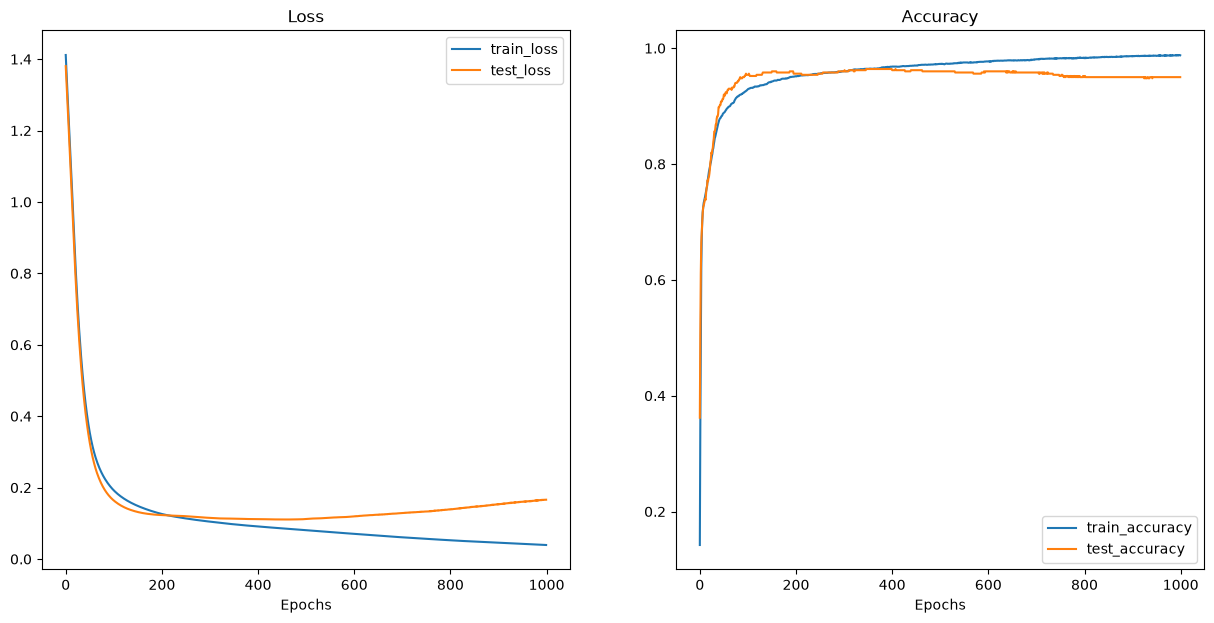

In [415]:
from helper_func import plot_loss_curves
plot_loss_curves({
    "train_loss":train_loss,
    "train_acc":train_acc,
    "test_loss":test_loss,
    "test_acc":test_acc
})

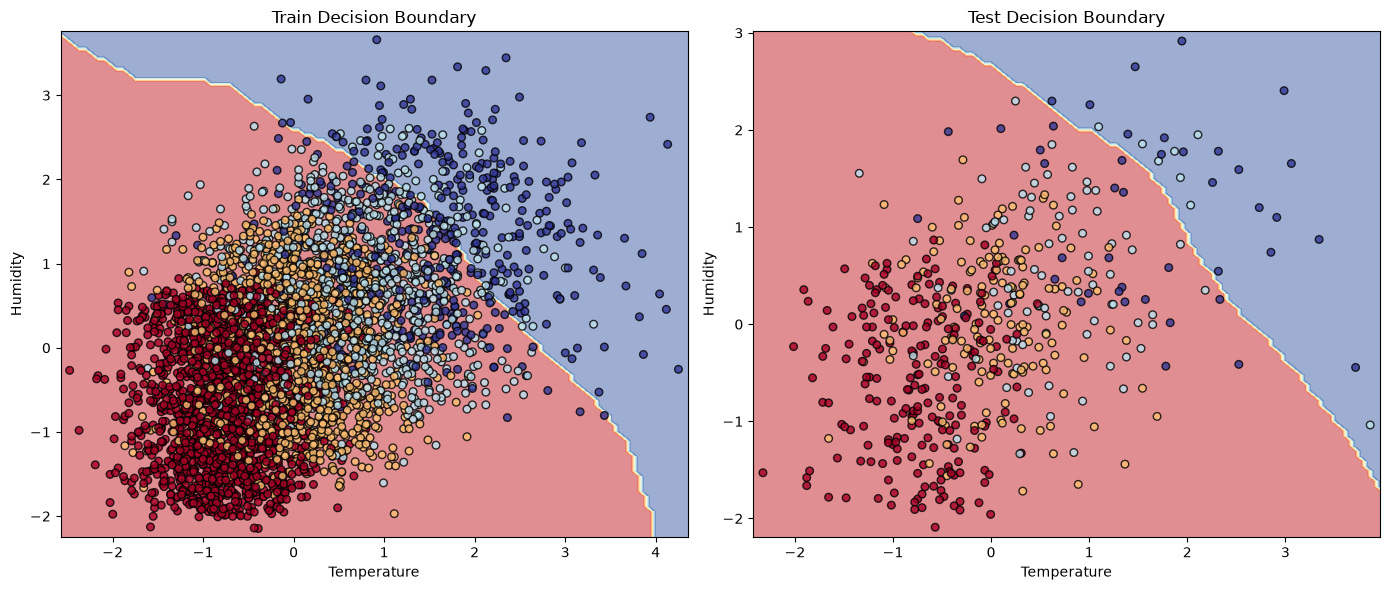

airQualityModel(
  (classification): Sequential(
    (0): Linear(in_features=9, out_features=81, bias=True)
    (1): ReLU()
    (2): Linear(in_features=81, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [417]:
features = list(features)

def plot_multifeature_decision_boundary(
    model: torch.nn.Module, 
    X: torch.Tensor, 
    y: torch.Tensor, 
    feature_indices=(0, 1), 
    feature_names=None      
):
    # Put everything to CPU
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")
    
    idx_x, idx_y = feature_indices

    # 1. Setup grid boundaries based on the two selected features
    x_min, x_max = X[:, idx_x].min() - 0.1, X[:, idx_x].max() + 0.1
    y_min, y_max = X[:, idx_y].min() - 0.1, X[:, idx_y].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # 2. FIXED: Use explicit integer size from the numpy grid
    grid_size = int(xx.size)
    baseline_features = torch.median(X, dim=0, keepdim=True).values.repeat(grid_size, 1)

    # 3. Overwrite the two chosen columns with our grid values
    baseline_features[:, idx_x] = torch.from_numpy(xx.ravel()).float()
    baseline_features[:, idx_y] = torch.from_numpy(yy.ravel()).float()

    # 4. Make predictions using the 9-feature grid template
    model.eval()
    with torch.inference_mode():
        y_logits = model(baseline_features)

    # Multi-class argmax calculation
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    # Reshape predictions back to grid dimensions
    y_pred = y_pred.reshape(xx.shape).numpy()
    
    # 5. Plot the background contours and original data scatter
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.5)
    plt.scatter(X[:, idx_x], X[:, idx_y], c=y, s=30, cmap=plt.cm.RdYlBu, edgecolor='k', alpha=0.8)
    
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    
    if feature_names:
        plt.xlabel(feature_names[idx_x])
        plt.ylabel(feature_names[idx_y])

        
        
plt.figure(figsize=(14, 6))

# Subplot 1: Train
plt.subplot(1, 2, 1)
plt.title("Train Decision Boundary")
plot_multifeature_decision_boundary(
    model=model, 
    X=X_train, 
    y=y_train, 
    feature_indices=(0, 1), # Visualizing column 0 vs column 1
    feature_names=features
)

# Subplot 2: Test
plt.subplot(1, 2, 2)
plt.title("Test Decision Boundary")
plot_multifeature_decision_boundary(
    model=model, 
    X=X_test, 
    y=y_test, 
    feature_indices=(0, 1),
    feature_names=features
)

plt.tight_layout()
plt.show()

# CRITICAL: Send your model back to your GPU device for future training!
model.to(device)


In [418]:
y_preds

tensor([2, 1, 1,  ..., 1, 0, 3], device='cuda:0')

In [419]:
y_train

tensor([2, 1, 1,  ..., 2, 0, 3], device='cuda:0')

In [420]:
y_logits

tensor([[ -8.9745,   2.1186,   8.3991,   2.3712],
        [ -8.0196,   9.0032,   6.4553,  -4.5151],
        [ -7.4044,  10.0430,   5.5199,  -7.5014],
        ...,
        [-11.2261,  10.3024,  10.1126,  -8.0642],
        [ 15.2627,  -6.6770, -15.1331,   0.8962],
        [-17.8695, -25.6657,  17.9791,  32.5443]], device='cuda:0',
       grad_fn=<AddmmBackward0>)